# [기초-실습] 통계 101x데이터 분석: (5-6장) 가설검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [14]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = "Malgun Gothic"  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 게임 아이템 뽑기 확률, 정말 10%일까? (난이도: 하)

**📘 문제**

- 어떤 게임 개발사에서 새로운 아이템의 뽑기 확률이 **10%**로 설정되었다고 주장하고 있습니다.

- 그런데 유저 커뮤니티에서는 "실제 확률은 10%보다 낮은 것 같다"는 의혹이 제기되었습니다.

- 이를 확인하기 위해 한 유저가 아이템을 **200번 뽑았고, 그중 12번 성공**했습니다.

- 이번 실습에서는 **이항검정(Binomial Test)**으로 이 결과가 개발사의 주장을 기각할 만큼 유의미한지 확인하고,
  시뮬레이션을 통해 **p-값이 무엇을 의미하는지**를 직접 눈으로 확인해 봅니다.

In [15]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 이항검정을 수행하여 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"만약 개발사의 주장대로 실제 확률이 정말 10%라면"** 200번 뽑기에서 성공 횟수가 어떻게 분포하는지 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 우리가 관찰한 '12번 성공'이 얼마나 희귀한 일인지 관찰해 봅시다.

In [16]:
# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 새로운 아이템 뽑기 확률은 10%다.
# H₁ (대립가설): 새로운 아이템 뽑기 확률은 10%보다 낮다.

In [17]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?

# 여기에 코드를 작성해주세요.
from scipy.stats import binomtest

n, k, p0 = 200, 12, 0.10
result = binomtest(k, n, p0, alternative='less')
print(result.pvalue)

0.0320465287969066


In [18]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

# 여기에 코드를 작성해주세요.
alpha = 0.05
if result.pvalue < alpha:
    print("H0 기각 → 실제 확률이 10%보다 낮다고 볼 수 있다")
else:
    print("H0 기각 실패 → 10%가 아니라고 볼 근거 부족")

H0 기각 → 실제 확률이 10%보다 낮다고 볼 수 있다


In [19]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(42)
sim = np.random.binomial(n=200, p=0.10, size=10000)

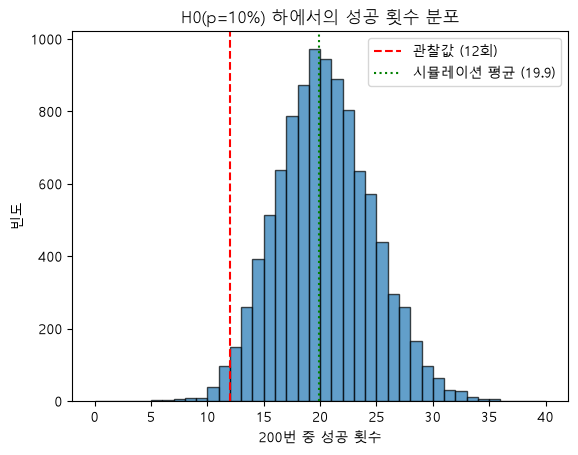

In [20]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
import matplotlib.pyplot as plt

plt.hist(sim, bins=range(0, 41), edgecolor='black', alpha=0.7)
plt.axvline(12, color='red', linestyle='--', label='관찰값 (12회)')
plt.axvline(sim.mean(), color='green', linestyle=':', label=f'시뮬레이션 평균 ({sim.mean():.1f})')
plt.xlabel('200번 중 성공 횟수')
plt.ylabel('빈도')
plt.title('H0(p=10%) 하에서의 성공 횟수 분포')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?  
: 성공 횟수가 12 이하로 나온 막대 그래프들의 넓이

- 시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?  
: 드문 일이다. 시뮬레이션 평균에서 멀리 떨어진 꼬리 부분에 위치한다.

- 이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?  
: 진짜 확률 10%를 가정하고 200번 뽑기를 10,000번 돌렸을 때, 12번 이하로 성공한 경우가 약 3% 밖에 되지 않는다.  
즉, "우연이라고 하기엔 너무 희귀해서 우연이 아니다(H0 기각)"라고 결론을 내리는 것이다.

- 만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?  
: 200번 뽑았을 때보다 훨씬 작아진다(4.38e-06).  200번 중 12번(6%)은 표본이 작아서 "그냥 운 나쁘게 이렇게 나왔을 수도 있잖아"라는 반박이 어느 정도 통하지만 (p=0.032), 1,000번 중 60번(6%)은 같은 6%지만, 그만큼 많이 뽑았는데도 계속 6%가 나왔다는 건 운으로 보기엔 너무 일관적이다 (p=0.0000044). 즉, 같은 6%라는 비율이어도 표본이 클수록 우연으로 설명하기 어려워진다.

In [21]:
binomtest(60, 1000, 0.10, alternative='less').pvalue

np.float64(4.378819902862784e-06)

# 문제 2. 과자 한 봉지의 중량은 150g이 맞을까? (난이도: 하)

**📘 문제**

- 한 식품 공장에서 생산하는 과자 한 봉지의 **목표 중량은 150g**입니다.

- 품질관리팀은 생산 공정이 목표 중량을 잘 맞추고 있는지 확인하기 위해,
  생산된 과자 **30봉지를 무작위로 추출**하여 무게를 측정했습니다.

- 이번 실습에서는 **일표본 t-검정(One-sample t-Test)**으로 표본 평균이 목표 중량과 유의미하게 다른지 검증하고,
  **"평균이 정확히 150g이라면"** 어떤 표본 평균들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

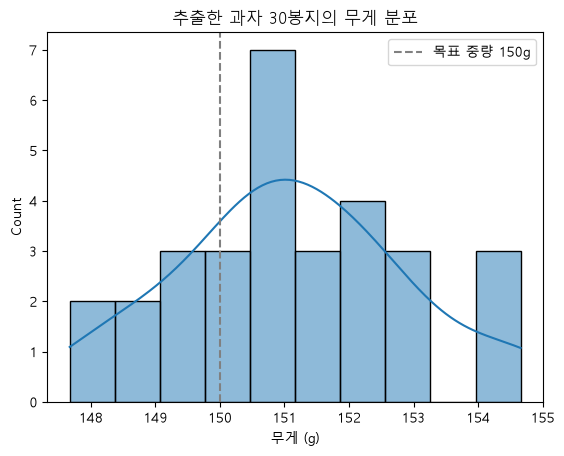

In [22]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 일표본 t-검정을 수행하여 t-통계량과 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"평균 무게가 정확히 150g이라면"** 30개짜리 표본의 평균이 어떻게 분포하는지 10,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 표본 평균이 그 분포에서 어디에 위치하는지 관찰해 봅시다.

In [23]:
# [문제 2] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 과자 한 봉지의 중량은 150 g이다.
# H₁ (대립가설): 과자 한 봉지의 중량은 150 g이 아니다.

In [24]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

# 여기에 코드를 작성해주세요.
from scipy.stats import ttest_1samp

target = 150
t_stat, p_value = ttest_1samp(sample_weights, target)
print("t-통계량:", t_stat)
print("p-값:", p_value)

t-통계량: 3.4193046824662683
p-값: 0.0018832640310520244


In [25]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

# 여기에 코드를 작성해주세요.
alpha = 0.05
if p_value < alpha:
    print("H0 기각 → 표본 평균이 150g과 유의미하게 다르다.")
else:
    print("H0 기각 실패 → 150g과 다르다고 볼 근거 부족")

H0 기각 → 표본 평균이 150g과 유의미하게 다르다.


In [26]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(42)

sample_std = np.std(sample_weights, ddof=1)  # 우리 표본의 표준편차 사용 (ddof=1: 표본표준편차)
n = len(sample_weights)  # 30

sim_means = []
for _ in range(10000):
    sample = np.random.normal(loc=150, scale=sample_std, size=n)  # H0(평균=150g)이 참이라고 가정
    sim_means.append(sample.mean())

sim_means = np.array(sim_means)

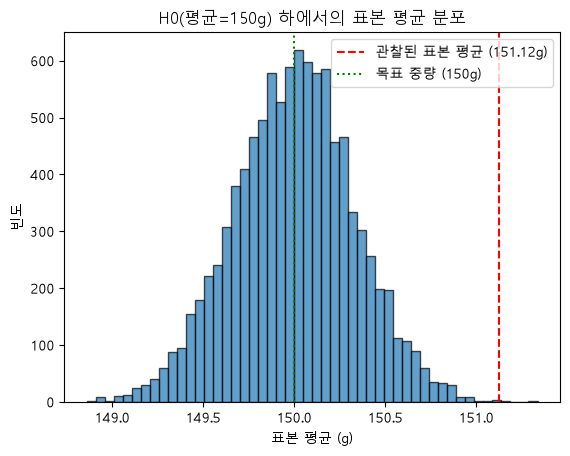

In [27]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
import matplotlib.pyplot as plt

observed_mean = np.mean(sample_weights)

plt.hist(sim_means, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(observed_mean, color='red', linestyle='--', label=f'관찰된 표본 평균 ({observed_mean:.2f}g)')
plt.axvline(150, color='green', linestyle=':', label='목표 중량 (150g)')
plt.xlabel('표본 평균 (g)')
plt.ylabel('빈도')
plt.title('H0(평균=150g) 하에서의 표본 평균 분포')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)  
: H0가 사실이라고 가정했을 때, 30개짜리 표본을 10,000번 뽑았을 때의 표본평균의 분포를 나타낸다.  
중심극한정리에 의해 표본크기가충분히 크면(30이상) 모집단의 분포와 상관없이 표본평균의 분포가 정규분포를 따르기 때문이다.

- 우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?  
: 실제로 관찰한 표본 평균(151.12 g)은 흔하게 나타나지 않는 값이다. p-값이 작을수록 세로선의 위치는 분포 중심에서 더 벗어나게 된다.

- 만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?  
: 현재 p-값(0.00188)보다 더 작은 p-값(0.001)이라면, 세로선은 지금보다 분포 중심에서 더 멀어질 것이다. 즉, 오른쪽으로 더 이동한 위치에 그려질 것이다.

- 이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)  
: 무게가 많이 나가면 봉지당 실제로 들어가는 원재료 양이 늘어나는 것이므로, 같은 가격에 더 많은 내용물을 제공하는 셈이다.   
이는 생산 원가 손실로 이어지게 때문에 생산 공정을 재점검해 평균에 가깝게 조정하고, 표준편차를 줄여서 봉지 마다의 편차가 크지 않도록 관리해야 한다.

# 문제 3. 어떤 온라인 학습 방식이 더 효과적일까? (난이도: 중)

**📘 문제**

- 한 교육 기업에서 두 가지 다른 온라인 학습 방식(A, B)을 개발했습니다.

- 방식 A가 방식 B보다 학생들의 성적 향상에 더 효과적인지 알아보기 위해,
  두 그룹의 학생들에게 각각 다른 방식으로 한 달간 학습시킨 후 시험을 보게 했습니다.

- 이번 실습에서는 **이표본 t-검정(Two-sample t-Test)**으로 두 방식의 평균 점수 차이를 검증합니다.
  단, t-검정의 기본 가정인 **정규성**과 **등분산성**을 먼저 확인해야 합니다.

- 또한 **"두 방식의 효과가 완전히 똑같다면"** 우연히 나타날 수 있는 점수 차이의 범위를 시뮬레이션으로 확인해 봅니다.

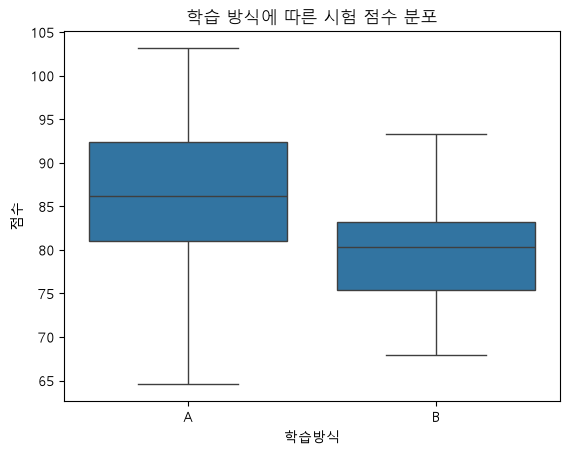

In [28]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                          '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 두 그룹에 대해 **정규성 검정(Shapiro-Wilk test)**을 수행해 봅시다. (H₀: 데이터는 정규분포를 따른다.)

- **등분산성 검정(Levene's test)**을 수행해 봅시다. (H₀: 두 그룹의 분산은 같다.)

- 가정 검토 결과에 따라 `equal_var` 인수를 설정하여 **이표본 t-검정**을 수행해 봅시다.

- 두 그룹 데이터를 모두 합친 뒤 무작위로 다시 나누는 방식으로, **"두 방식의 효과가 같을 때"**의 평균 차이 분포를 시뮬레이션해 봅시다.

In [29]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.

# 여기에 코드를 작성해주세요.
from scipy import stats

shapiro_a = stats.shapiro(group_a_scores)
shapiro_b = stats.shapiro(group_b_scores)

print("A그룹 Shapiro:", shapiro_a)
print("B그룹 Shapiro:", shapiro_b)

A그룹 Shapiro: ShapiroResult(statistic=np.float64(0.9876454398276279), pvalue=np.float64(0.8765532982892831))
B그룹 Shapiro: ShapiroResult(statistic=np.float64(0.9865736574349925), pvalue=np.float64(0.8365820936119768))


In [30]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.

# 여기에 코드를 작성해주세요.
levene_result = stats.levene(group_a_scores, group_b_scores)
print("Levene:", levene_result)

Levene: LeveneResult(statistic=np.float64(6.133009626946852), pvalue=np.float64(0.01498158908561773))


In [31]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

# 여기에 코드를 작성해주세요.
t_stat, p_value = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=False)
print("t-통계량:", t_stat)
print("p-값:", p_value)

t-통계량: 4.0425693188528316
p-값: 0.00011486850389345317


In [32]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(0)
combined = np.concatenate([group_a_scores, group_b_scores])  # 100명 전체 합치기

sim_diffs = []
for _ in range(10000):
    perm = np.random.permutation(combined)  # 100명을 무작위로 섞기
    sim_a = perm[:50]   # 앞 50명 = 가상 A그룹
    sim_b = perm[50:]   # 뒤 50명 = 가상 B그룹
    sim_diffs.append(sim_a.mean() - sim_b.mean())

sim_diffs = np.array(sim_diffs)

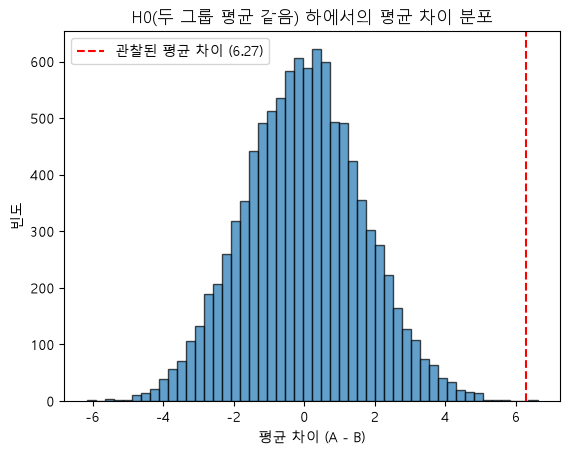

In [33]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
observed_diff = group_a_scores.mean() - group_b_scores.mean()

plt.hist(sim_diffs, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(observed_diff, color='red', linestyle='--', label=f'관찰된 평균 차이 ({observed_diff:.2f})')
plt.xlabel('평균 차이 (A - B)')
plt.ylabel('빈도')
plt.title('H0(두 그룹 평균 같음) 하에서의 평균 차이 분포')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?  
: 정규성 검정의 p-값(0.88, 0.84)은 유의수준(0.05) 보다 높아 H0를 기각하지 못하기 때문에 데이터는 정규분포를 따른다고 해석할 수 있다.  
등분산성 검정의 p-값(0.015)은 유의수준(0.05) 보다 낮아 H0가 기각되므로, 두 그룹의 분산은 같지 않다고 해석된다.  
이표본 t-검정의 조건인 등분산성을 만족시키지 못하기 때문에 웰치 t-검정을 사용해야 한다.

- Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?  
: 두 그룹의 평균이 같다라는 귀무가설이 참이라고 가정한 상태에서 실제 그룹을 무시하고 무작위로 재배정한 것을 10,000번 반복한 분포이기 때문이다. 즉, 두 방식의 효과가 같다면 평균 차이는 0에 가깝게 형성된다.

- 실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?  
: 실제로 관찰된 평균 차이는 6.27로, 우연히 나타날 수 있는 범위를 벗어난다.

- 이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?  
: 세로선(관찰된 평균 차이)이 분포의 중심에서 얼마나 멀리 떨어져 있는지가 먼저 정해지고, 그 위치를 기준으로 "이보다 극단적인 값이 나올 비율"을 계산한 것이 p-값이다.

- 통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?  
: A방식과 B방식 사이의 유의미한 차이(A방식이 평균 약 6점 더 높음)가 확인되었다.  
    1. A방식을 표준 커리큘럼으로 채택하거나 확대 도입  
    2. 왜 A방식이 더 효과적인지 요인 분석  
    3. 마케팅에 "A방식 도입 시 평균 성적 6점 향상"과 같은 문구를 사용  
    4. B방식을 이미 사용 중인 기존 고객에게 A방식으로 전환 유도 또는 업그레이드 상품 제안

# 문제 4. 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)

**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


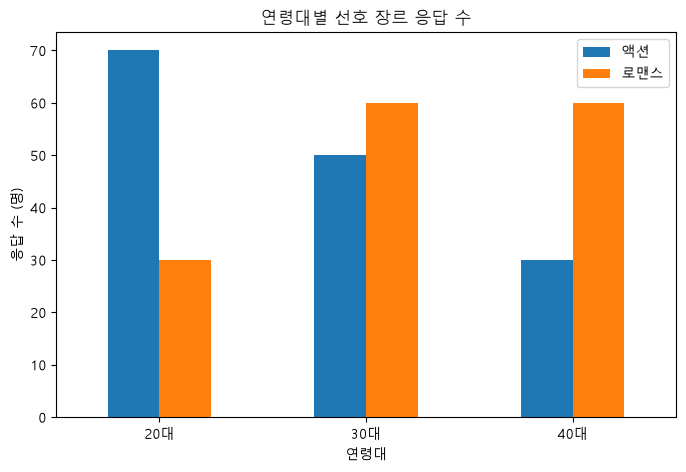

In [34]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [35]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 연령대와 선호 장르는 아무 관련이 없다(독립이다).
# H₁ (대립가설): 연령대와 선호 장르는 관련이 있다(독립이 아니다).

In [36]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.

# 여기에 코드를 작성해주세요.
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(observed.values)

print("카이제곱 통계량:", chi2.round(2))
print("p-값:", p_value)
print("자유도:", dof)

expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
print("기대 빈도:")
print(expected_df)

카이제곱 통계량: 26.91
p-값: 1.4347133934125667e-06
자유도: 2
기대 빈도:
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0


In [37]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산

# 여기에 코드를 작성해주세요.
np.random.seed(42)

n = observed.values.sum()  # 300
age_labels = observed.index.tolist()      # ['20대', '30대', '40대']
genre_labels = observed.columns.tolist()  # ['액션', '로맨스']

# 힌트1: 전체 비율을 확률로 사용
age_probs = observed.sum(axis=1) / n      # 각 연령대의 전체 비율
genre_probs = observed.sum(axis=0) / n    # 각 장르의 전체 비율

sim_chi2 = []
for _ in range(5000):
    # 힌트2: 독립적으로 연령대와 장르를 각각 무작위 할당
    sim_age = np.random.choice(age_labels, size=n, p=age_probs.values)
    sim_genre = np.random.choice(genre_labels, size=n, p=genre_probs.values)
    
    # 힌트3: 가상 분할표 생성 후 카이제곱 통계량 계산
    sim_table = pd.crosstab(sim_age, sim_genre)
    sim_stat, _, _, _ = chi2_contingency(sim_table)
    sim_chi2.append(sim_stat)

sim_chi2 = np.array(sim_chi2)

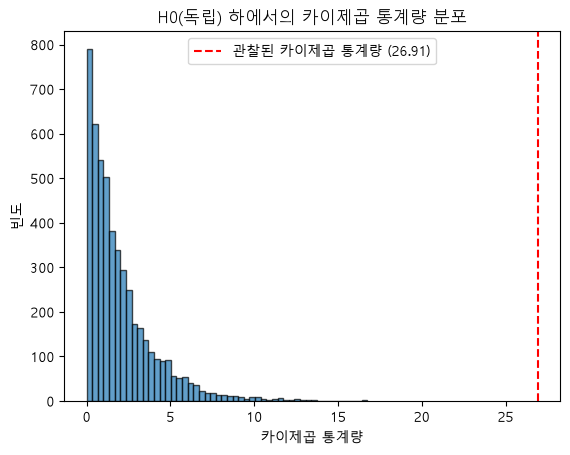

In [38]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
plt.hist(sim_chi2, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(chi2, color='red', linestyle='--', label=f'관찰된 카이제곱 통계량 ({chi2:.2f})')
plt.xlabel('카이제곱 통계량')
plt.ylabel('빈도')
plt.title('H0(독립) 하에서의 카이제곱 통계량 분포')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?  
: 기대빈도 = (행 합계 × 열 합계) / 전체 합계  
기대 빈도는 "만약 두 변수가 완전히 무관하다"면 나왔어야 할 이론적인 값 즉, H0(독립)가 참일 때 이론적으로 나와야 할 값을 의미한다.  
카이제곱 = Σ (관측빈도 - 기대빈도)² / 기대빈도 이므로 관측빈도와 차이가 클수록 카이제곱 통계량이 증가한다.

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?  
: H0가 사실이라고 가정하고 얻은 시뮬레이션을 5,000번 반복했을 때의 카이제곱 통계량 분포를 시각화한 것이다.  
실제 관찰된 카이제곱 통계량(26.91)은 극단적인 값이다. 시뮬레이션 5,000번 중 26.91 이상 나온 경우가 0번(0%)이었으므로, 독립이라는 가정 하에서는 사실상 나오기 불가능한 값이다.

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?  
: p-value(약 1.43e-06)가 유의수준(0.05)보다 작기 때문에 H0는 기각된다. 즉, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있다.


- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?  
관측 vs 기대 비교 결과:
    - 20대: 액션 실제 70명 (기대 50명 대비 +20명) → 액션 선호가 뚜렷하게 높음
    - 40대: 액션 실제 30명 (기대 45명 대비 -15명) → 로맨스 선호가 뚜렷하게 높음
    - 30대: 기대치와 큰 차이 없음 (액션 50명 vs 기대 55명) → 특별한 쏠림 없음  

  전략:  
    - 연령대별 타겟 프로모션  
        20대: 액션 영화 + 콜라보 굿즈(피규어, 포스터) 패키지, 액션 신작 개봉 시 SNS 이벤트, 친구 동반 할인  
        40대: 로맨스 영화 + 저녁 식사 패키지, 부부/커플 대상 좌석 업그레이드 할인  
        공통: 연령대 인증 기반 앱 푸시 알림으로 "당신이 좋아할 만한 신작" 추천  
    - 멤버십/데이터 활용  
        연령대별 장르 선호 데이터를 멤버십 시스템에 반영해서, 예매 시 개인화된 추천 순위 노출

# 문제 5. 미니 프로젝트 - 어떤 신규 비료가 가장 효과적일까? (난이도: 상)

**📘 문제**

- 한 농업 연구소에서 새로 개발한 비료 3종류(A, B, C)의 생산량 증대 효과를 비교하고자 합니다.

- 동일한 조건의 밭 30개를 준비하여, 각각 10개씩 비료 A, B, C를 투여한 후 수확량을 측정했습니다.

- 이번 실습에서는 **분산분석(ANOVA)**으로 세 비료 간 평균 수확량에 차이가 있는지 검증하고,
  차이가 있다면 **사후분석(Tukey's HSD)**으로 어떤 비료끼리 차이가 나는지 확인합니다.

- 마지막으로 **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량이 나올 수 있는지 시뮬레이션하고,
  분석 결과를 바탕으로 연구소에 어떤 비료를 추천할지까지 생각해 봅니다.

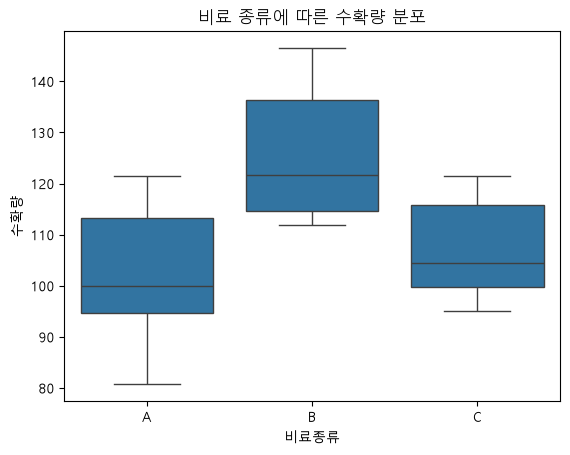

In [39]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 세 그룹에 대해 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.

- ANOVA 결과가 유의미할 경우에만 **Tukey's HSD 사후분석**을 수행하고 결과를 해석해 봅시다.

- **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량들이 나오는지 5,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 F-통계량이 얼마나 극단적인 값인지 확인해 봅시다.

- 분석 결과를 종합하여 연구소에 추천할 비료를 정해 봅시다.

In [40]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

# 여기에 코드를 작성해주세요.
f_stat, p_value = stats.f_oneway(fertilizer_a, fertilizer_b, fertilizer_c)
print("F-통계량:", f_stat)
print("p-값:", p_value)

F-통계량: 10.345510578794014
p-값: 0.0004618664585149297


In [41]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

# 여기에 코드를 작성해주세요.
from statsmodels.stats.multicomp import pairwise_tukeyhsd

all_data = np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c])
groups = ['A']*10 + ['B']*10 + ['C']*10

if p_value < 0.05:
    tukey = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
    print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  23.6754 0.0006  10.0402 37.3106   True
     A      C   4.8429 0.6569  -8.7923 18.4781  False
     B      C -18.8325 0.0054 -32.4677 -5.1972   True
-----------------------------------------------------


In [42]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

# 여기에 코드를 작성해주세요.
np.random.seed(123)
all_data = np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c])
pooled_mean = all_data.mean()   # 111.81
pooled_std = all_data.std(ddof=1)  # 15.77

sim_f = []
for _ in range(5000):
    g1 = np.random.normal(pooled_mean, pooled_std, 10)
    g2 = np.random.normal(pooled_mean, pooled_std, 10)
    g3 = np.random.normal(pooled_mean, pooled_std, 10)
    f, _ = stats.f_oneway(g1, g2, g3)
    sim_f.append(f)

sim_f = np.array(sim_f)

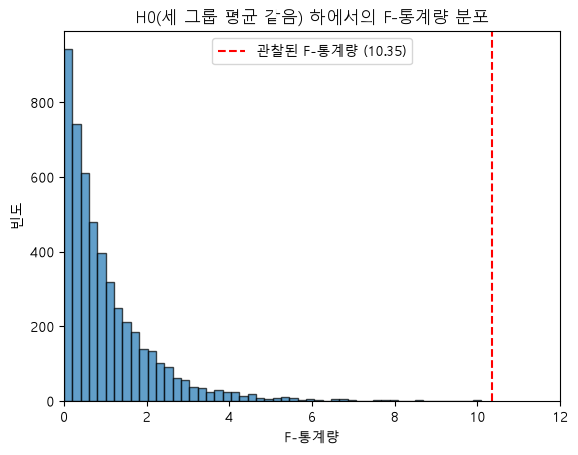

In [43]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.
plt.hist(sim_f, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(f_stat, color='red', linestyle='--', label=f'관찰된 F-통계량 ({f_stat:.2f})')
plt.xlabel('F-통계량')
plt.ylabel('빈도')
plt.title('H0(세 그룹 평균 같음) 하에서의 F-통계량 분포')
plt.legend()
plt.xlim(0, 12)
plt.show()

In [44]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?
# 여기에 의견을 작성해주세요.
# B비료를 우선 도입할 것을 권장한다. 
# ANOVA 검정 결과 F = 10.35, p = 0.000462로, 세 비료 중 적어도 하나는 평균 수확량이 다르다는 것을 확인하였고, 
# Tukey 사후분석을 통해 구체적으로 B-A, B-C 비교에서 B가 유의미하게 높다는 것을 확인하였기 때문이다.
# 하지만, B비료의 표준편차가 세 비료 중 가장 크기 때문에 수확량 변동성이 실제로 문제가 되는지 추가적인 분산 비교 검정 수행이 필요하다.

**🧠 데이터를 어떻게 읽을까요?**

- ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?  
: p-값이 0.000462으로, 유의수준(0.05) 보다 작기 때문에 H0을 기각한다. 이는 세 비료 중 적어도 하나는 다르다는 의미이다.

- Tukey's HSD 결과표의 `reject` 열에서 `True`로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?  
: A-B, B-C 조합이 reject = True 이다. reject = True는 "두 그룹의 평균 차이가 통계적으로 유의미하다(0이 아니라고 볼 수 있다)"는 뜻이다. 즉, "이 두 비료는 효과가 다르다"고 결론 내릴 수 있다.  
반대로 A-C가 False라는 건, "A와 C 사이의 차이는 우연(표본 변동)으로 설명 가능한 수준이라 통계적으로 다르다고 단정할 수 없다"는 의미이다.

- `meandiff` 열의 값은 어떤 정보를 주나요? 신뢰구간(`lower`, `upper`)이 0을 포함하는지 여부는 무엇을 뜻할까요?  
: meandiff는 두 그룹 평균의 실제 차이값을 의미한다.(예: B-A = 23.68은 "B가 A보다 평균 23.68 더 높다"는 뜻)  
신뢰구간이 0을 포함하지 않음 → "평균 차이가 0이 아니다"라고 확신할 수 있음 → reject=True  
신뢰구간이 0을 포함함 → "평균 차이가 0일 수도 있다"는 가능성을 배제 못함 → reject=False


- 그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?  
: 표본이 작으면 표준오차가 커져서 신뢰구간이 넓어지고, 신뢰구간이 넓어지면 0을 포함하는지에 대한 판정이 우연한 표본 변동에 더 민감해진다.  
표본의 크기를 확대하거나 다른 계절, 다른 지역 밭에서 재현 실험을 진행해 결과의 일관성 확인한다.  
단순히 유의미한지, 비유의미한지로 끝내지 않고, 신뢰구간 폭을 함께 제시하여 불확실성도 공유한다.